
Осциллятор ван дер Поля: $\ddot{x}-(\lambda-x^2)\dot{x}+\omega_{0}^2x=0$

### Карта седел

$$
\dot{x} = y = 0\\
\dot{y} = (\lambda - x^2) y - \omega_0^2 x = 0 \\
\\
J = \begin{bmatrix}
  0 & 
    1 \\[1ex]
  -2xy-\omega_{0}^2 & 
    \lambda - x^2 \\[1ex]
\end{bmatrix} \\
J_{x=y=0} = \begin{bmatrix}
  0 & 
    1 \\[1ex]
  -\omega_{0}^2 & 
    \lambda \\[1ex]
\end{bmatrix} \\
\mu^2 - \lambda \mu + \omega_0^2 = 0 \\
\mu_{1,2} = \frac{\lambda \pm \sqrt{\lambda^2 - 4 \omega_0^2}}{2}
$$

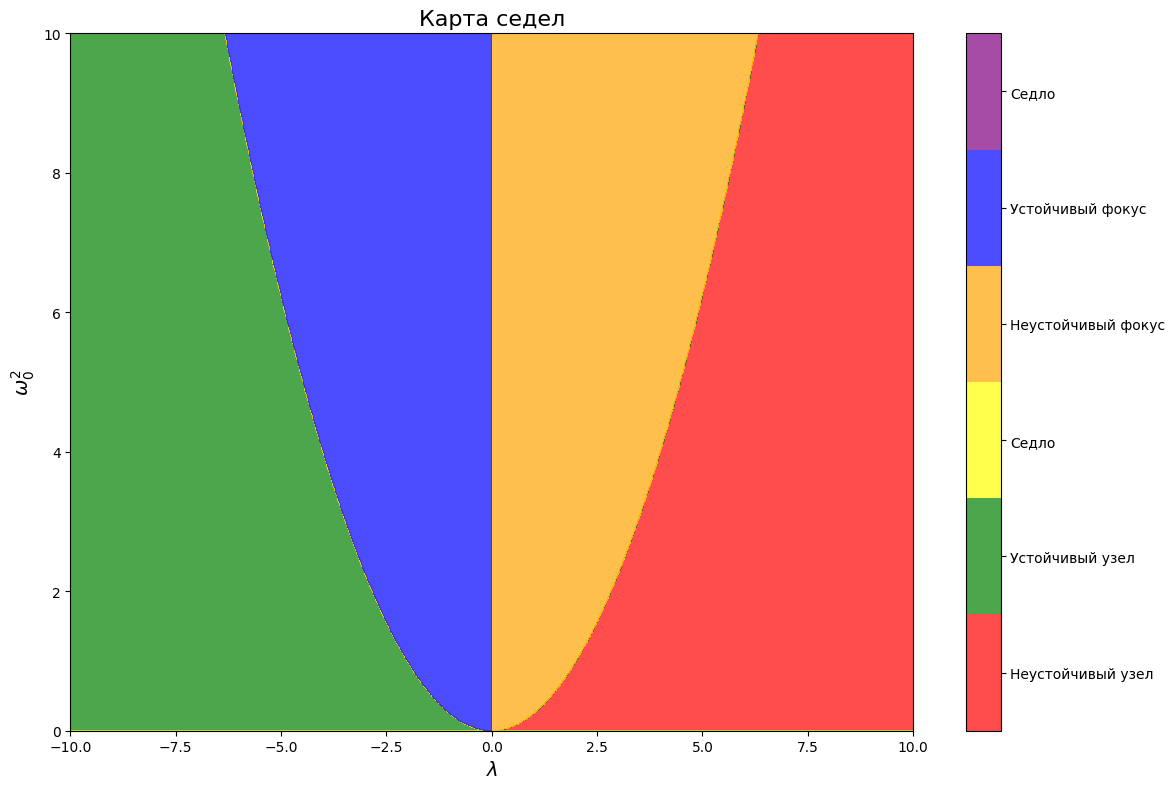

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def get_equilibrium_type(lambda_val, w0_sq_val):
    D = lambda_val**2 - 4 * w0_sq_val
    
    if D > 0:
        l1 = (lambda_val + np.sqrt(D)) / 2
        l2 = (lambda_val - np.sqrt(D)) / 2
        if l1 > 0 and l2 > 0:
            return 1  # неустойчивый узел
        elif l1 < 0 and l2 < 0:
            return 2  # устойчивый узел
        else:
            return 3  # седло
    elif D < 0:
        real_part = lambda_val / 2
        if real_part > 0:
            return 4  # неустойчивый фокус
        elif real_part < 0:
            return 5  # устойчивый фокус
        else:
            return 6  # центр
    else:  # D == 0
        real_part = lambda_val / 2
        if real_part > 0:
            return 1  # неустойчивый узел
        elif real_part < 0:
            return 2  # устойчивый узел
        else:
            return 6  # центр

def get_equilibrium_type_map(lambda_vals, w0_sq_vals):
    Lambda, W0_sq = np.meshgrid(lambda_vals, w0_sq_vals)
    equilibrium_type = np.zeros_like(Lambda)
    for i in range(len(lambda_vals)):
        for j in range(len(w0_sq_vals)):
            equilibrium_type[j, i] = get_equilibrium_type(lambda_vals[i], w0_sq_vals[j])
    return equilibrium_type


lambda_vals = np.linspace(-10, 10, 1000)
w0_sq_vals = np.linspace(0, 10, 1000)

equilibrium_type = get_equilibrium_type_map(lambda_vals, w0_sq_vals)

type_labels = {
    1: 'Неустойчивый узел',
    2: 'Устойчивый узел', 
    3: 'Седло',
    4: 'Неустойчивый фокус',
    5: 'Устойчивый фокус',
    6: 'Седло'
}

plt.figure(figsize=(12, 8))
contour = plt.contourf(lambda_vals, w0_sq_vals, equilibrium_type, 
                      levels=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
                      colors=['red', 'green', 'yellow', 'orange', 'blue', 'purple'], 
                      alpha=0.7)

cbar = plt.colorbar(contour, ticks=[1, 2, 3, 4, 5, 6])
cbar.ax.set_yticklabels([type_labels[i] for i in [1, 2, 3, 4, 5, 6]])

plt.xlabel(r'$\lambda$', fontsize=14)
plt.ylabel(r'$\omega_0^2$', fontsize=14)
plt.title('Карта седел', fontsize=16)

plt.tight_layout()
plt.show()

### Карта максимальных амплитуд

In [1]:
import numpy as  np
from utils.trajectories import grid_of_amplitude 
from systems.van_der_pol_rk4 import van_der_pol_rk4


x = np.linspace(-5, 5, 20)
y = np.linspace(0, 5, 20)
Z = grid_of_amplitude(van_der_pol_rk4, [0.6, 0.7], [x, y], 0.01, 20, 20, lambda x: x[0])

Вычисление сетки (по строкам): 100%|██████████| 20/20 [02:28<00:00,  7.43s/it]


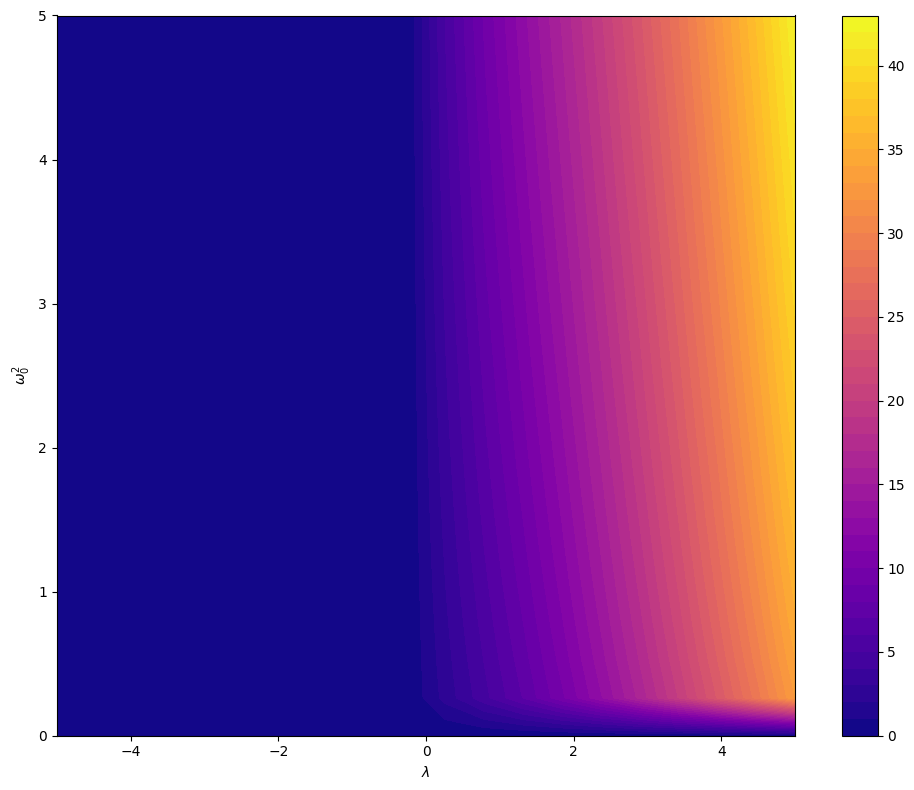

In [2]:
from utils.plots import plot_heatmap

plot_heatmap(x, y, Z, x_label=r'$\lambda$', y_label=r'$\omega_0^2$')

Вычисление сетки (по строкам): 100%|██████████| 50/50 [21:41<00:00, 26.03s/it]    


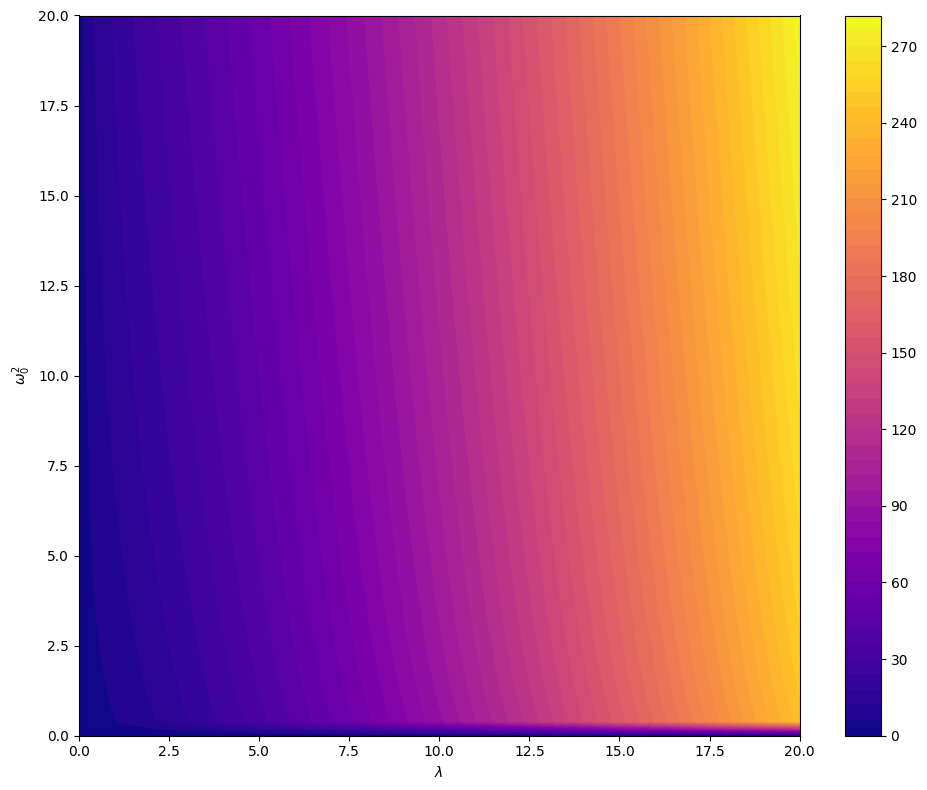

In [3]:
import numpy as  np
from utils.trajectories import grid_of_amplitude 
from systems.van_der_pol_rk4 import van_der_pol_rk4
from utils.plots import plot_heatmap

x = np.linspace(0, 20, 50)
y = np.linspace(0, 20, 50)
Z = grid_of_amplitude(van_der_pol_rk4, [1.1, 3.1], [x, y], 0.01, 20, 20, lambda x: x[0])

plot_heatmap(x, y, Z, x_label=r'$\lambda$', y_label=r'$\omega_0^2$')

### Фазовые портреты

In [1]:
from utils.trajectories import get_attractor_trajectory
from utils.plots import plot_trajectory
from systems.van_der_pol_rk4 import van_der_pol_rk4

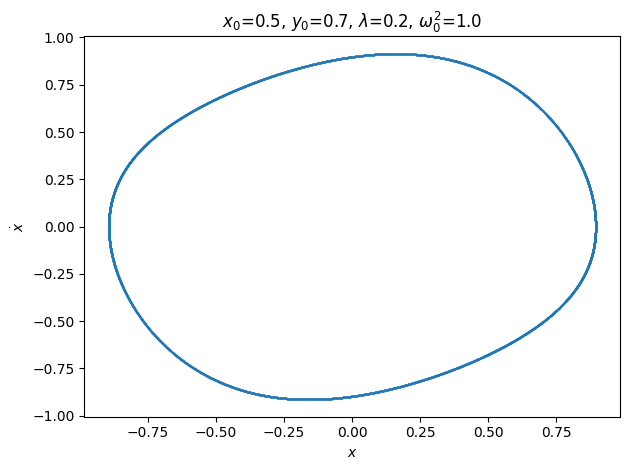

In [6]:
plot_trajectory(get_attractor_trajectory(van_der_pol_rk4, [0.5, 0.7], [0.2, 1], 0.01, 50, 50, lambda x: x[1]), title=fr'$x_0$=0.5, $y_0$=0.7, $\lambda$=0.2, $\omega_0^2$=1.0')

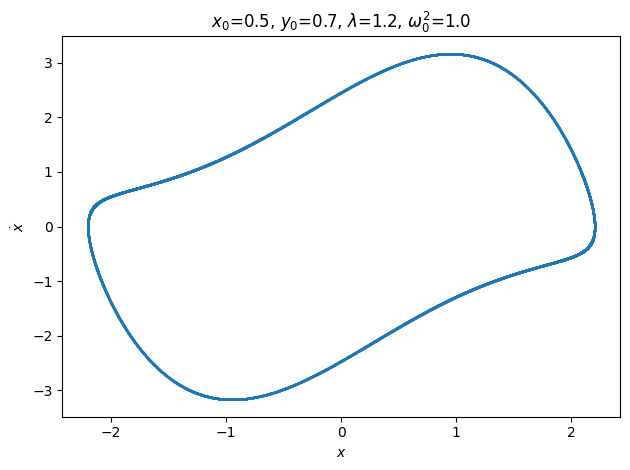

In [7]:
plot_trajectory(get_attractor_trajectory(van_der_pol_rk4, [0.5, 0.7], [1.2, 1], 0.01, 50, 50, lambda x: x[1]), title=fr'$x_0$=0.5, $y_0$=0.7, $\lambda$=1.2, $\omega_0^2$=1.0')

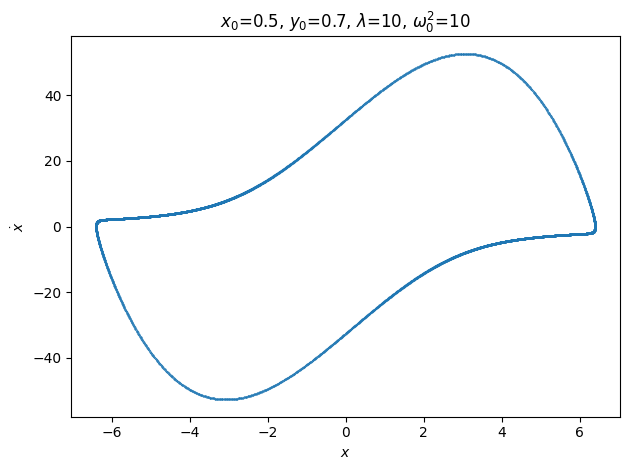

In [8]:
plot_trajectory(get_attractor_trajectory(van_der_pol_rk4, [0.5, 0.7], [10, 10], 0.01, 50, 50, lambda x: x[1]), title=fr'$x_0$=0.5, $y_0$=0.7, $\lambda$=10, $\omega_0^2$=10')